In [1]:
import json
import requests
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
import pandas as pd

url = "https://kukau.org/avg_air_temp_solar_rain.json" 

In [25]:
csv = "../data/koror.csv"
data = pd.read_csv(csv)
data

,Date,MaxTemperature,AvgTemperature,Precipitation
0,1951-07-01,90,82.5,0.00
1,1951-07-02,89,82.5,0.03
2,1951-07-03,87,81.0,0.15
3,1951-07-04,84,79.0,0.72
4,1951-07-05,88,81.5,0.00
...,...,...,...,...
27187,2025-12-06,86,81.5,0.26
27188,2025-12-07,87,82.5,0.11
27189,2025-12-08,87,83.0,0.00
27190,2025-12-09,88,82.5,0.13


In [27]:
data['Date'] = pd.to_datetime(data['Date'])
data['Precipitation'] = pd.to_numeric(data['Precipitation'].str.strip(), errors='coerce')
data['MaxTemperature'] = pd.to_numeric(data['MaxTemperature'].str.strip(), errors='coerce')
data['AvgTemperature'] = pd.to_numeric(data['AvgTemperature'].str.strip(), errors='coerce')

Text(0.5, 1.0, 'Daily Precipitation by Month')

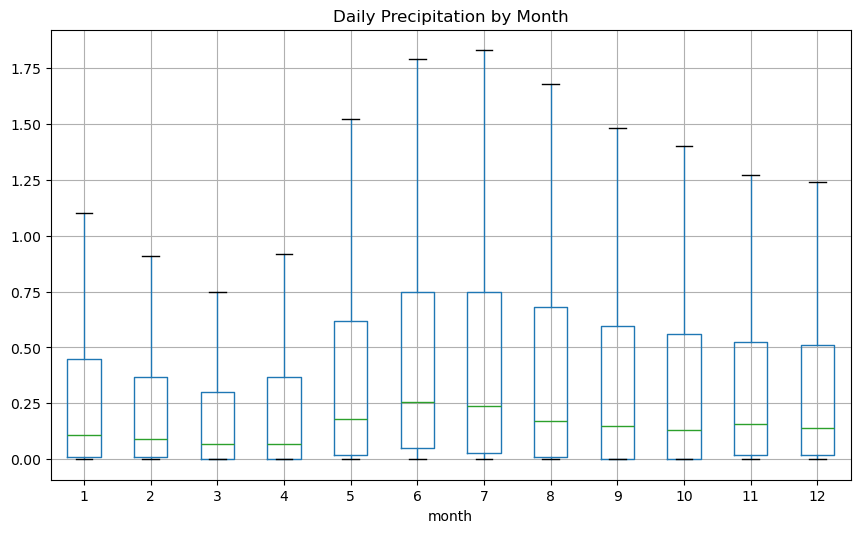

In [44]:
import matplotlib.pyplot as plt

data['month'] = data['Date'].dt.month

data.boxplot(
    column='Precipitation',
    by='month',
    showfliers=False,
    figsize=(10, 6)
)

plt.suptitle('')
plt.title('Daily Precipitation by Month')

Text(0.5, 1.0, 'Daily Precipitation by Month')

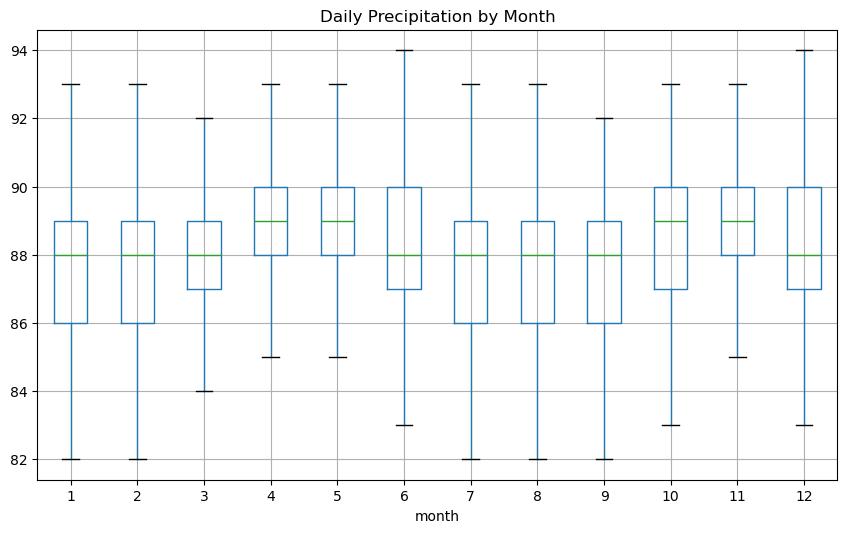

In [46]:
data['month'] = data['Date'].dt.month

data.boxplot(
    column='MaxTemperature',
    by='month',
    showfliers=False,
    figsize=(10, 6)
)

plt.suptitle('')
plt.title('Daily Precipitation by Month')

<Axes: >

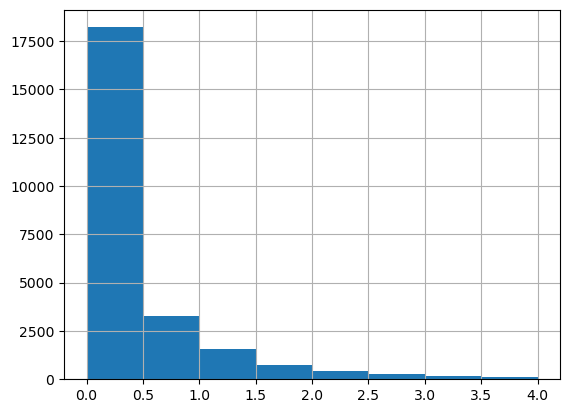

In [24]:
import numpy as np
bins = np.arange(
    0,
    4 + 0.5,
    0.5
)

data['Precipitation'].hist(bins=bins)

In [7]:
response = requests.get(url)
response.raise_for_status()
data = response.json()

for d in data:
    d["day"] = datetime.strptime(d["day"], "%Y-%m-%d").date()

#In Palau timezone
palau_tz = ZoneInfo("Pacific/Palau")
today = datetime.now(palau_tz).date()
yesterday = today - timedelta(days=1)

# Filter records for yesterday
yesterday_data = [
    {
        "station_no": d["station_no"],
        "station_name": d["station_name"],
        "date": d["day"].isoformat(),
        "avg_air_temp": d["avg_air_temp"],
        "rain_mm": d["rain_mm"],
        "rain_in": d["rain_in"]
    }
    for d in data if d["day"] == yesterday
]

# Save to JSON file
with open("../data/latest_weather.json", "w") as f:
    json.dump(yesterday_data, f, indent=2)
